In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487060202230
V1.0.0.7
V21.2

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V5V-791.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2221 entries, 0 to 2220
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2221 non-null   str  
 1   Message  2221 non-null   str  
 2   Status   2221 non-null   str  
dtypes: str(3)
memory usage: 52.2 KB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252523    803
0x252513    787
0x252514    593
0x252501     22
0x252511     16
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2221 entries, 0 to 2220
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2221 non-null   str  
 1   Message  2221 non-null   str  
 2   Status   2221 non-null   str  
 3   Headers  2221 non-null   str  
dtypes: str(4)
memory usage: 69.5 KB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1380 entries, 0 to 2220
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             1380 non-null   str  
 1   Message             1380 non-null   str  
 2   Status              1380 non-null   str  
 3   Headers             1380 non-null   str  
 4   Odometer in meters  1380 non-null   int64
 5   Date                1380 non-null   str  
 6   Raw data            1380 non-null   str  
dtypes: int64(1), str(6)
memory usage: 86.2 KB
None


260925011126 -> 0 -> 120867.0 -> 0x252513005900EE0869487060202230007838402D00000059510000000000640000000000000000FFFFFFFFFFFF00D50001D82300260925011126669E1245A42B8FC2E52183C1000000BC03951264FFFFFF0000160000FFFFFF
260925051126 -> 1 -> 120867.0 -> 0x252513005900EF0869487060202230007838402D000000594F0000000000640000000000000000FFFFFFFFFFFF00D50001D82300260925051126669E1245A42B8FC2E52183C1000000BC03941258FFFFFF0000110000FFFFFF
260925091126 -> 2 -> 120867.0 -> 0x252513005900F00869487060202230007838402D000000594E0000000000640000000000000000FFFFFFFFFFFF00D50001D82300260925091126669E1245A42B8FC2E52183C1000000BC03941260FFFFFF00000F0000FFFFFF
260925093004 -> 3 -> 120867.0 -> 0x252514005900900869487060202230007838402D000000594E0000000000641000000000000000FFFFFFFFFFFF44D50001D82300260925093004669E1245A42B8FC2E52183C1000000BC03941259FFFFFF00000F0000FFFFFF
260925093019 -> 4 -> 120867.0 -> 0x252514005900910869487060202230007838402D0000004F4E0000000000641000000000000000FFFFFFFFFFFF79D50001D8230026092

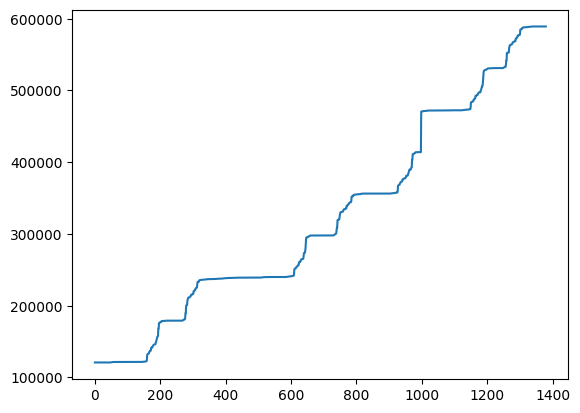

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [7]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


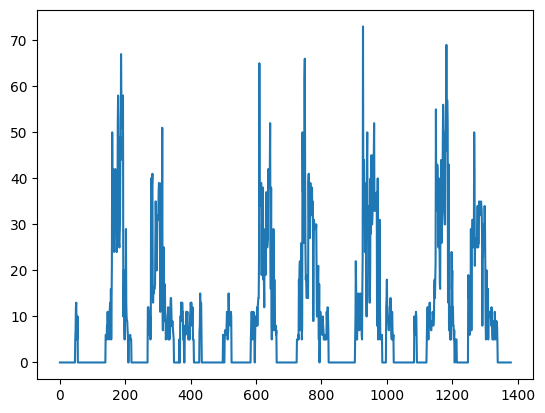

In [8]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

Satellites Number

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 1380 entries, 0 to 2220
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         1380 non-null   str  
 1   Message                         1380 non-null   str  
 2   Status                          1380 non-null   str  
 3   Headers                         1380 non-null   str  
 4   Satellites                      1380 non-null   int64
 5   Satellite_connection_indicator  1380 non-null   int64
 6   Raw data                        1380 non-null   str  
 7   date                            1380 non-null   str  
dtypes: int64(2), str(6)
memory usage: 97.0 KB
Eventos históricos:  0


Coordinates

In [11]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 1380 entries, 0 to 2220
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            1380 non-null   str    
 1   Message            1380 non-null   str    
 2   Status             1380 non-null   str    
 3   Headers            1380 non-null   str    
 4   Latitude           1380 non-null   str    
 5   Latitude_decoded   1380 non-null   float64
 6   Longitude          1380 non-null   str    
 7   Longitude_decoded  1380 non-null   float64
 8   Raw data           1380 non-null   str    
 9   Date               1380 non-null   str    
 10  Speed              1380 non-null   int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 129.4 KB
None
260925011126 -> E52183C1 -> -16.391550064086914 -> A42B8FC2 -> -71.58523559570312 0x252513005900EE0869487060202230007838402D00000059510000000000640000000000000000FFFFFFFFFFFF00D50001D82300260925011126669E1245A42B8FC2E521

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [12]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V5V-791_in_outs.csv')

<class 'pandas.DataFrame'>
Index: 1380 entries, 0 to 2220
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1380 non-null   str  
 1   Message  1380 non-null   str  
 2   Status   1380 non-null   str  
 3   Headers  1380 non-null   str  
dtypes: str(4)
memory usage: 53.9 KB


Ignition

In [13]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 1380 entries, 0 to 1379
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  1380 non-null   str  
 1   date         1380 non-null   str  
 2   raw data     1380 non-null   str  
dtypes: str(3)
memory usage: 43.1 KB
Ignition Off 0b0
Ignition Off 0b0
Ignition Off 0b0
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Ignition On 0b1000000000000
Igniti

Door detection

In [14]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [15]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V5V-791_in_outs.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   1380 non-null   int64
 1   in and outs  1380 non-null   str  
 2   date         1380 non-null   int64
 3   raw data     1380 non-null   str  
dtypes: int64(2), str(2)
memory usage: 43.3 KB


Panic detection

In [16]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  1380 non-null   str  
 1   date         1380 non-null   str  
 2   raw data     1380 non-null   str  
dtypes: str(3)
memory usage: 32.5 KB


In [17]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

iButton

In [18]:
id_button_m=raw_data[raw_data['Headers'].str.contains('0x252523')]
device_id=[]
id_button_date=[]

for i in range(0,id_button_m.shape[0]):
    device_id.append(id_button_m.iloc[i,2][84:100])
    id_button_date.append(id_button_m.iloc[i,2][32:44])
    print(id_button_m.iloc[i,2][84:100],id_button_m.iloc[i,2][32:44])

id_button_m['date']=id_button_date
id_button_m['device_id']=device_id

yymmdd=[]

for i in range(0,id_button_m.shape[0]):
    yymmdd.append(id_button_m.iloc[i,2][32:38])

id_button_m['yymmdd']=yymmdd
id_button_m.info()

FF00001C74EB4D01 260925093018
FF00001C74EB4D01 260925093018
FF00001C74EB4D01 260925093020
FF00001C74EB4D01 260925093020
FF00001C74EB4D01 260925093021
FF00001C74EB4D01 260925093021
FF00001C74EB4D01 260925093022
FF00001C74EB4D01 260925093022
FF00001C74EB4D01 260925093023
FF00001C74EB4D01 260925093024
FF00001C74EB4D01 260925093024
FF00001C74EB4D01 260925093025
FF00001C74EB4D01 260925093025
FF00001C74EB4D01 260925093026
FF00001C74EB4D01 260925093026
FF00001C74EB4D01 260925093027
FF00001C74EB4D01 260925093027
FF00001C74EB4D01 260925093028
FF00001C74EB4D01 260925093028
FF00001C74EB4D01 260925093029
FF00001C74EB4D01 260925093029
FF00001C74EB4D01 260925093030
FF00001C74EB4D01 260925093030
FF00001C74EB4D01 260925093031
FF00001C74EB4D01 260925093031
FF00001C74EB4D01 260925093032
FF00001C74EB4D01 260925093032
FF00001C74EB4D01 260925093033
FF00001C74EB4D01 260925093033
FF00001C74EB4D01 260925093034
FF00001C74EB4D01 260925093034
FF00001C74EB4D01 260925093035
FF00001C74EB4D01 260925093035
FF00001C74

In [19]:
id_button_m['yymmdd'].value_counts()

yymmdd
260925    360
260930    268
260928     97
261002     78
Name: count, dtype: int64

log de conductores

In [20]:
log=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\Drivers Log Report_es.xlsx')
sn='V5V-791'
log_v5v_791=log[log['Unidad'].str.contains(sn)]
log_v5v_791

,Conductor,Unidad,Unnamed: 2,Entrada,Unnamed: 4,Dirección / Landmark,Unnamed: 6,Unnamed: 7,Unnamed: 8,Salida,Unnamed: 10,Dirección / Landmark.1
28,"ARAPA ARAPA, HENRY JAVIER",V5V-791,NaN,23/09/2026 04:43 a.m.,NaN,"Av Pe-34 A-48, Cerro Colorado, Arequipa, Arequ...",NaN,NaN,NaN,25/09/2026 02:11 p.m.,NaN,"Av Pe-34 A-51, Cerro Colorado, Arequipa, Arequ..."
29,"ARAPA ARAPA, HENRY JAVIER",V5V-791,NaN,28/09/2026 04:31 a.m.,NaN,"Av Pe-34 A-54, Cerro Colorado, Arequipa, Arequ...",NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\hl_v5v791.xlsx')
hl['Eventos'].value_counts()

Eventos
Desplazándose - Ign. apagada    459
iButton Conectado               422
Estacionado                     332
Entrada 2 Activada               25
Entrada 2 Desactivada            24
Saliendo de Landmark             15
Entrando a Landmark              15
Name: count, dtype: int64